This notebook contain an isolated version of the musical notes detection algorithm.
Notice that there are 2 versions:

1) The first one uses the red line (like the project itself). This is better when using low resolution cameras and wanting percies detection. There might be small changes between this and the original version. For seeing the original you can look at full_python_code.py.

2) The second one doesnt use a red line and instead it uses a function fitEllipse. It works better with high resolutions.


In [1]:
from google.colab import files
from IPython.display import Image


uploaded = files.upload()

import cv2
import numpy as np
from google.colab import files
from IPython.display import Image
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt







# Upload a new file
##uploaded = files.upload()

# Get the uploaded file name
uploaded_filename = list(uploaded.keys())[0]




Saving cropped_image.jpeg to cropped_image.jpeg


Detected Staff Line Y-Positions:
  Line 1: y = 20
  Line 2: y = 49
  Line 3: y = 78
  Line 4: y = 106
  Line 5: y = 136

Red Line Y-Position: y = 180
Detected Note: C4


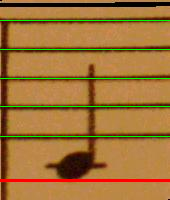

In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from google.colab.patches import cv2_imshow

def find_and_filter_staff_lines(binary_image, max_lines=5, spacing_tolerance=0.6):
    projection = np.sum(binary_image, axis=1)
    threshold = 0.7 * np.max(projection)
    potential_lines = np.where(projection > threshold)[0]
    top_margin=10

    # Filter out lines too close to the top of the image
    potential_lines = potential_lines[potential_lines > top_margin]

    if len(potential_lines) == 0:
        return []

    line_clusters = []
    current_cluster = [potential_lines[0]]
    for i in range(1, len(potential_lines)):
        if potential_lines[i] == potential_lines[i-1] + 1:
            current_cluster.append(potential_lines[i])
        else:
            line_clusters.append(current_cluster)
            current_cluster = [potential_lines[i]]
    line_clusters.append(current_cluster)

    line_positions = [int(np.mean(cluster)) for cluster in line_clusters]
    line_positions.sort()

    spacing_estimates = np.diff(line_positions)
    if len(spacing_estimates) == 0:
        return []

    avg_spacing = np.median(spacing_estimates)

    filtered_lines = [line_positions[0]]
    for pos in line_positions[1:]:
        if pos - filtered_lines[-1] > spacing_tolerance * avg_spacing:
            filtered_lines.append(pos)
        if len(filtered_lines) == max_lines:
            break

    return filtered_lines


def detect_red_line(image):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    lower_red1 = np.array([0, 70, 50])
    upper_red1 = np.array([10, 255, 255])
    lower_red2 = np.array([170, 70, 50])
    upper_red2 = np.array([180, 255, 255])
    red_mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
    red_mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
    red_mask = cv2.bitwise_or(red_mask1, red_mask2)

    red_projection = np.sum(red_mask, axis=1)
    red_y = np.argmax(red_projection)

    if red_projection[red_y] > 50:
        return red_y
    else:
        return None






def determine_note(note_center, staff_lines):
    """
    Determine the note's name based on its y-coordinate relative to the staff lines.

    Args:
        note_center (float): Y-coordinate of the note's center.
        staff_lines (list): List of y-coordinates of the detected staff lines.

    Returns:
        str: The musical note name (e.g., "E4", "F4").
    """
    # Ensure staff lines are sorted from top (low y-value) to bottom (high y-value)
    staff_lines = sorted(staff_lines)

    # Define note names for the standard 5-line staff
    # Notes are assigned from top to bottom: F5, E5, D5, C5, B4, A4, G4, F4, E4, D4
    note_names = ["F5", "E5", "D5", "C5", "B4", "A4", "G4", "F4", "E4", "D4","C4","B3","A3","G3"]


    # Calculate the average spacing between staff lines
    if len(staff_lines) >= 2:
        avg_spacing = (staff_lines[-1] - staff_lines[0]) / (len(staff_lines) - 1)
        tolerance = avg_spacing / 8
    else:
        raise ValueError("At least 2 staff lines are required to determine note positions.")

    # Handle notes above the top staff line
    if note_center < staff_lines[0]:
        # Calculate how many steps above the top line the note is
        steps_above = int((staff_lines[0] - note_center) / (avg_spacing / 2))
        return note_names[steps_above]

    # Handle notes between staff lines
    for i in range(len(staff_lines) - 1):
        upper_line = staff_lines[i]
        lower_line = staff_lines[i + 1]

        if upper_line < note_center < lower_line:   #if upper_line <= note_center < lower_line:
            # Divide the space between the lines into 2 regions (line and space)
            region_height = (lower_line - upper_line) / 2 #half of the space between two lines
            if note_center < upper_line + region_height: #closer to the lower line
                print(i)
                return note_names[i * 2 ]  # Line note previous: return note_names[i * 2]
            else:
                print(i)
                return note_names[i * 2+1]  # Space note  previous: return note_names[i * 2 + 1]
        if abs(note_center - upper_line) <= tolerance:
          return note_names[i * 2-1]


    # Handle notes below the bottom staff line
    if note_center >= staff_lines[-1]:
        # Calculate how many steps below the bottom line the note is
        steps_below = int((note_center - staff_lines[-1]) / (avg_spacing / 2))
      #  return note_names[-steps_below - 1]
        return note_names[7+steps_below]

    # If no condition is met, return None (should not happen)
    return None

# === Main Flow ===
image = cv2.imread(uploaded_filename)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
binary = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                               cv2.THRESH_BINARY_INV, 15, 2)

staff_lines = find_and_filter_staff_lines(binary, max_lines=5)
red_line_y = detect_red_line(image)

# Draw lines
output = image.copy()
print("Detected Staff Line Y-Positions:")
for i, y in enumerate(staff_lines):
    print(f"  Line {i+1}: y = {y}")
    cv2.line(output, (0, y), (output.shape[1], y), (0, 255, 0), 1)

if red_line_y is not None:
    print(f"\nRed Line Y-Position: y = {red_line_y}")
    cv2.line(output, (0, red_line_y), (output.shape[1], red_line_y), (0, 0, 255), 2)

    note = determine_note(red_line_y, staff_lines)
    print(f"Detected Note: {note}")
else:
    print("\nRed line not detected.")

cv2_imshow(output)


Second Algorithm

In [3]:
from google.colab import files
from IPython.display import Image


uploaded2 = files.upload()

import cv2
import numpy as np
from google.colab import files
from IPython.display import Image
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt







# Upload a new file
##uploaded = files.upload()

# Get the uploaded file name
uploaded_filename2 = list(uploaded2.keys())[0]




Saving BQ.jpg to BQ.jpg


Detected 1 notes.

Note Found: B4 at (x=57, y=80)


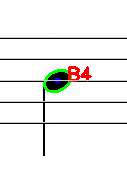

In [4]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from google.colab.patches import cv2_imshow

# --- Staff Line Detection ---

def find_and_filter_staff_lines(binary_image, max_lines=5, spacing_tolerance=0.6):
    projection = np.sum(binary_image, axis=1)
    threshold = 0.7 * np.max(projection)
    potential_lines = np.where(projection > threshold)[0]
    top_margin = 10

    potential_lines = potential_lines[potential_lines > top_margin]
    if len(potential_lines) == 0: return [], []

    line_clusters = []
    current_cluster = [potential_lines[0]]
    for i in range(1, len(potential_lines)):
        if potential_lines[i] == potential_lines[i-1] + 1:
            current_cluster.append(potential_lines[i])
        else:
            line_clusters.append(current_cluster)
            current_cluster = [potential_lines[i]]
    line_clusters.append(current_cluster)

    line_positions = [int(np.mean(cluster)) for cluster in line_clusters]
    line_heights = [len(cluster) for cluster in line_clusters]

    # Sort both based on positions
    combined = sorted(zip(line_positions, line_heights))
    line_positions, line_heights = zip(*combined)

    spacing_estimates = np.diff(line_positions)
    if len(spacing_estimates) == 0: return [], []

    avg_spacing = np.median(spacing_estimates)

    filtered_lines = [line_positions[0]]
    filtered_heights = [line_heights[0]]

    for i in range(1, len(line_positions)):
        if line_positions[i] - filtered_lines[-1] > spacing_tolerance * avg_spacing:
            filtered_lines.append(line_positions[i])
            filtered_heights.append(line_heights[i])
        if len(filtered_lines) == max_lines:
            break

    return filtered_lines, filtered_heights

# --- Image Repair (Inpainting) ---

def remove_lines_with_inpainting(gray_image, staff_lines, line_heights):
    """Fills in the gaps where staff lines were so notes remain solid ovals."""
    mask = np.zeros_like(gray_image)
    for line, height in zip(staff_lines, line_heights):
        # We make the mask slightly thicker than the line to ensure clean removal
        start = max(line - height // 2 - 1, 0)
        end = min(line + height // 2 + 1, gray_image.shape[0] - 1)
        mask[start:end, :] = 255
    return cv2.inpaint(gray_image, mask, 3, cv2.INPAINT_TELEA)

# --- Note Detection ---

def detect_note_heads_ellipse(clean_gray, min_area=30):
    """Detects note heads by filtering out staff lines and fitting ellipses."""
    # 1. Threshold to get black objects
    binary_notes = cv2.adaptiveThreshold(clean_gray, 255,
                                        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                        cv2.THRESH_BINARY_INV, 11, 2)

    # 2. MORPHOLOGICAL FILTERING (The "Secret Sauce")
    # This kernel is a small square. Opening will remove anything
    # thinner than the square (like leftover lines/stems).
    kernel = np.ones((3, 3), np.uint8)
    binary_notes = cv2.morphologyEx(binary_notes, cv2.MORPH_OPEN, kernel)

    # 3. Find contours
    contours, _ = cv2.findContours(binary_notes, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    note_ellipses = []

    for cnt in contours:
        if len(cnt) >= 5:
            area = cv2.contourArea(cnt)
            # We want the area to be small (just the note head),
            # not the whole staff. Try adjusting max_area if needed.
            if 20 < area < 500:
                ellipse = cv2.fitEllipse(cnt)
                major, minor = max(ellipse[1]), min(ellipse[1])
                ratio = major / (minor + 1e-5)

                # Note heads are slightly oval, usually ratio 1.0 to 1.8
                if 0.9 < ratio < 1.8:
                    note_ellipses.append(ellipse)
    return note_ellipses

# --- Musical Logic ---

def determine_note(note_center, staff_lines):
    staff_lines = sorted(staff_lines)
    # Mapping for Treble Clef
    note_names = ["F5", "E5", "D5", "C5", "B4", "A4", "G4", "F4", "E4", "D4", "C4", "B3", "A3", "G3"]

    if len(staff_lines) < 2: return "Unknown"

    avg_spacing = (staff_lines[-1] - staff_lines[0]) / (len(staff_lines) - 1)

    # Check notes relative to lines
    if note_center < staff_lines[0]:
        steps_above = int(round((staff_lines[0] - note_center) / (avg_spacing / 2)))
        return note_names[max(0, 0 - steps_above)] if steps_above < len(note_names) else "Way Above"

    for i in range(len(staff_lines) - 1):
        upper_line = staff_lines[i]
        lower_line = staff_lines[i + 1]
        midpoint = (upper_line + lower_line) / 2

        # Is it closer to the line or the space?
        if upper_line <= note_center < lower_line:
            if abs(note_center - upper_line) < (avg_spacing / 4):
                return note_names[i * 2] # On the line
            elif abs(note_center - midpoint) < (avg_spacing / 4):
                return note_names[i * 2 + 1] # In the space
            else:
                return note_names[i * 2 + 1]

    if note_center >= staff_lines[-1]:
        steps_below = int(round((note_center - staff_lines[-1]) / (avg_spacing / 2)))
        idx = 8 + steps_below
        return note_names[idx] if idx < len(note_names) else "Way Below"

    return None

# === Main Flow ===

# 1. Image Loading and Basic Prep
image = cv2.imread(uploaded_filename2)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
binary = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY_INV, 15, 2)

# 2. Staff Detection
staff_lines, heights = find_and_filter_staff_lines(binary, max_lines=5)

if staff_lines:
    # 3. Image Repair & Note Detection
    clean_gray = remove_lines_with_inpainting(gray, staff_lines, heights)
    note_ellipses = detect_note_heads_ellipse(clean_gray)

    output = image.copy()
    print(f"Detected {len(note_ellipses)} notes.\n")

    # 4. Process Each Note Found
    for el in note_ellipses:
        center_y = el[0][1]
        center_x = el[0][0]

        # Determine and Print Note
        note_name = determine_note(center_y, staff_lines)
        print(f"Note Found: {note_name} at (x={int(center_x)}, y={int(center_y)})")

        # Draw results: Green ellipse and blue center dot
        cv2.ellipse(output, el, (0, 255, 0), 2)
        cv2.circle(output, (int(center_x), int(center_y)), 3, (255, 0, 0), -1)
        cv2.putText(output, note_name, (int(center_x) + 10, int(center_y)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

    # Draw staff lines for reference
    for y in staff_lines:
        cv2.line(output, (0, y), (output.shape[1], y), (200, 200, 200), 1)

    cv2_imshow(output)
else:
    print("Could not detect staff lines.")